In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)



In [2]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [4]:
df.shape

(45000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [6]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [9]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

In [10]:
num_col = df.select_dtypes(include=['int64','float64']).columns.tolist()

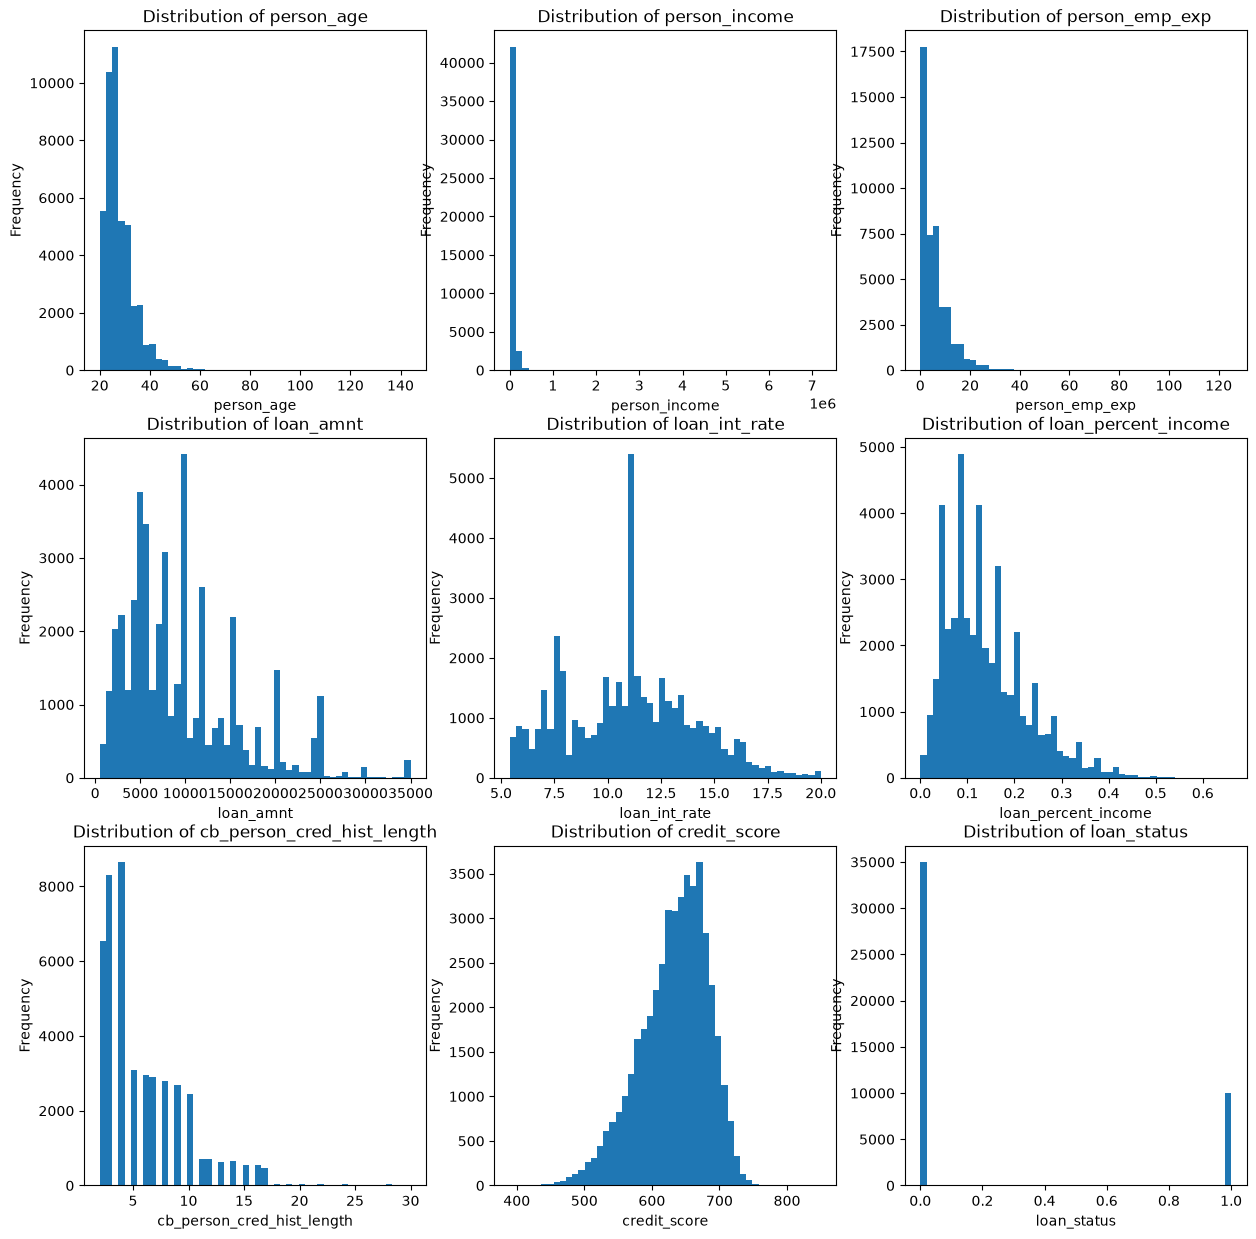

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes_flat = axes.flatten()

for ax,col in zip(axes_flat,num_col):
    ax.hist(df[col],bins = 50)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')


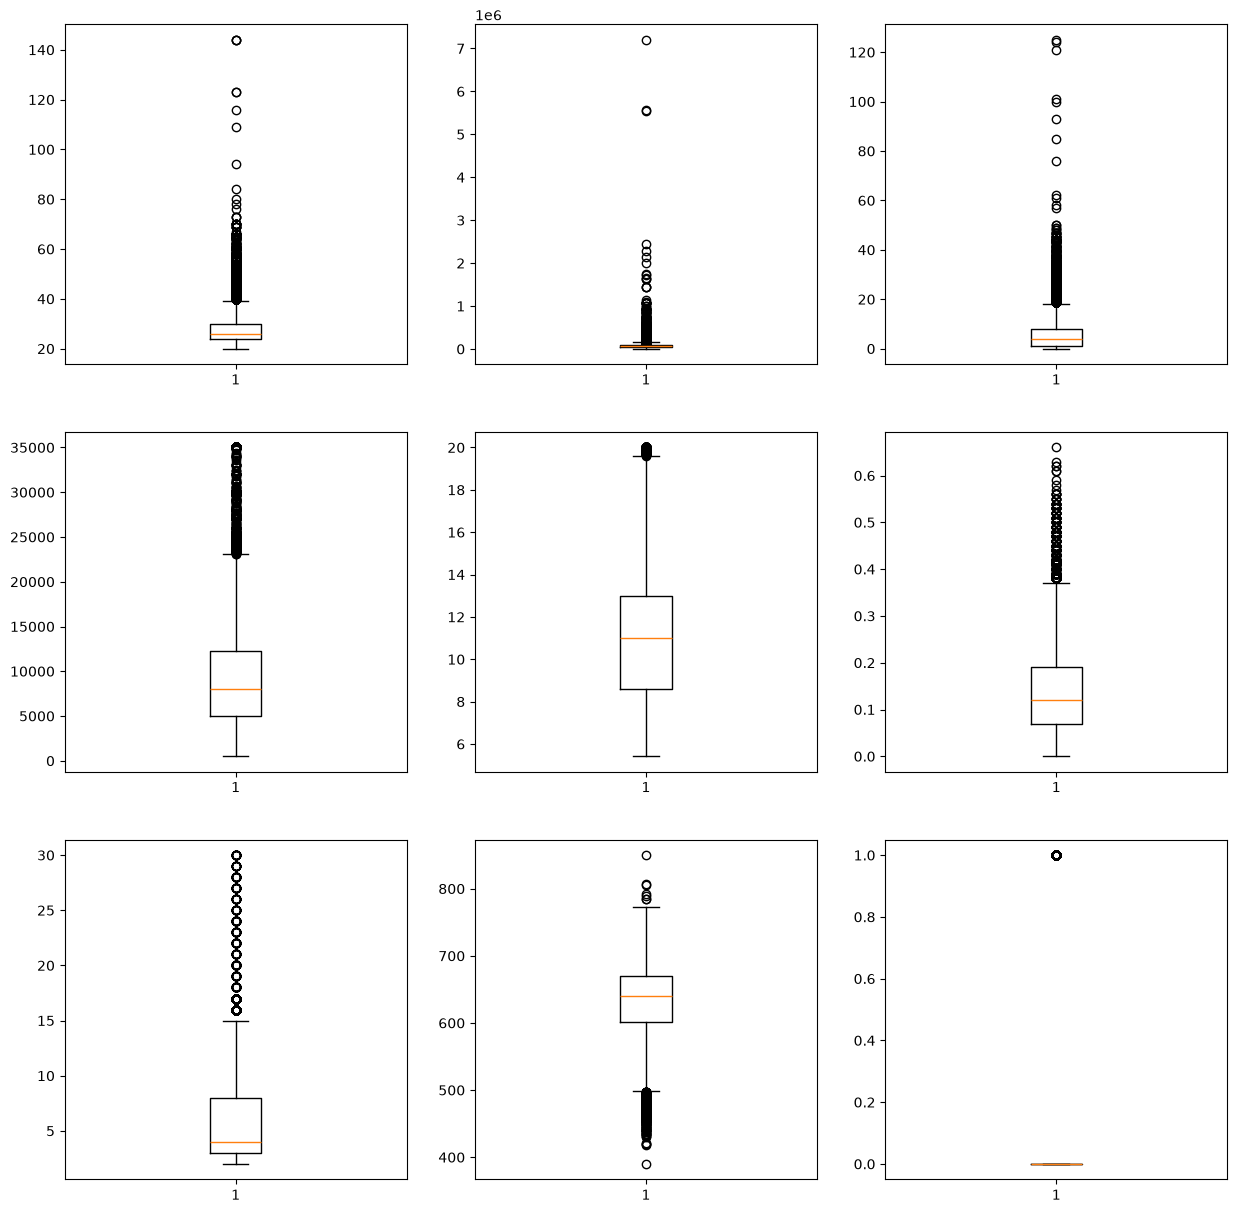

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes_flat = axes.flatten()

for ax,col in zip(axes_flat,num_col):
    ax.boxplot(df[col])

In [14]:
cat_col = df.select_dtypes(include=['str']).columns.tolist()

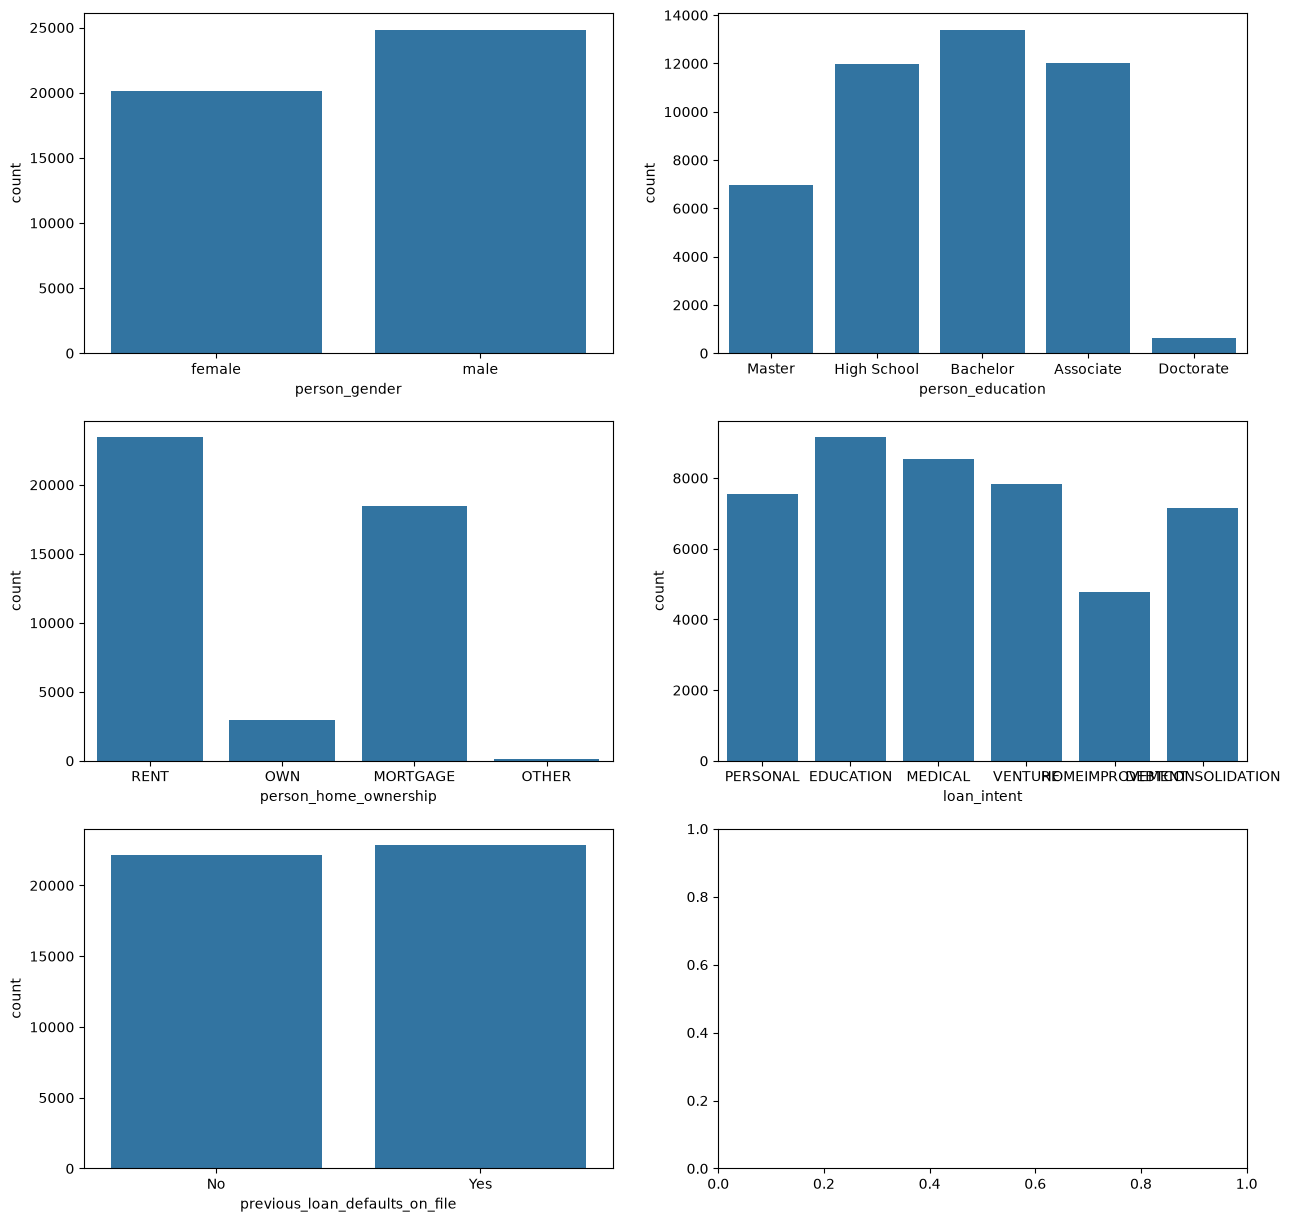

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes_flat = axes.flatten()

for ax,col in zip(axes_flat,cat_col):
    sns.countplot(data = df,x = df[col],ax= ax)

<Axes: xlabel='loan_status', ylabel='credit_score'>

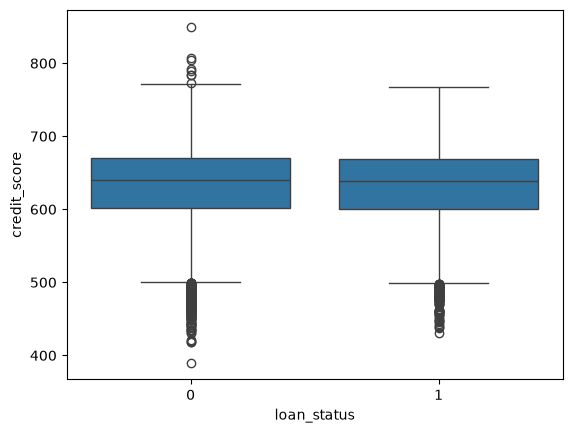

In [16]:
sns.boxplot(data = df,x= 'loan_status',y = 'credit_score')

In [17]:
df.groupby('loan_status')['credit_score'].median()

loan_status
0    640.0
1    639.0
Name: credit_score, dtype: float64

<Axes: xlabel='loan_status', ylabel='person_income'>

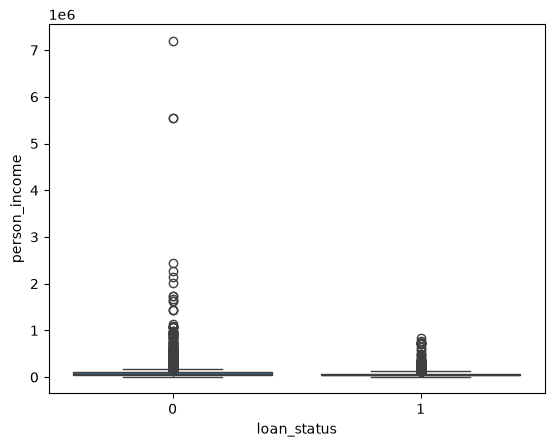

In [18]:
sns.boxplot(data = df,x= 'loan_status',y = 'person_income')

In [19]:
Q1 = df['person_age'].quantile(0.25)

In [20]:
Q3 = df['person_age'].quantile(0.75)

In [21]:
IQR = Q3 - Q1

In [22]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [23]:
df[(df['person_age']<lower )|(df['person_age']>upper)].shape

(2188, 14)

In [24]:
df[df['person_age']>100].shape

(7, 14)

In [25]:
upper

np.float64(39.0)

In [26]:
Q1_p = df['person_emp_exp'].quantile(0.25)
Q3_p = df['person_emp_exp'].quantile(0.75)
IQR_p = Q3_p - Q1_p
lower_p = Q1_p - 1.5*IQR_p
upper_p = Q3_p + 1.5*IQR_p

In [27]:
df[(df['person_emp_exp']<lower_p)|(df['person_age']>upper_p)].shape

(45000, 14)

In [28]:
upper_fill= 50   

In [29]:
lower_p

np.float64(-9.5)

In [30]:
new_df_cap = df.copy()

new_df_cap['person_age'] = np.where(
    new_df_cap['person_age'] > upper,
    upper,
    np.where(
        new_df_cap['person_age'] < lower,
        lower,
        new_df_cap['person_age']
    )
)

In [31]:

new_df_cap['person_emp_exp'] = np.where(
    new_df_cap['person_emp_exp'] > upper_fill,
    upper_fill,new_df_cap['person_emp_exp']
)

In [32]:
new_df_cap

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [33]:
num_df = new_df_cap.select_dtypes(include=['int64','float64'])

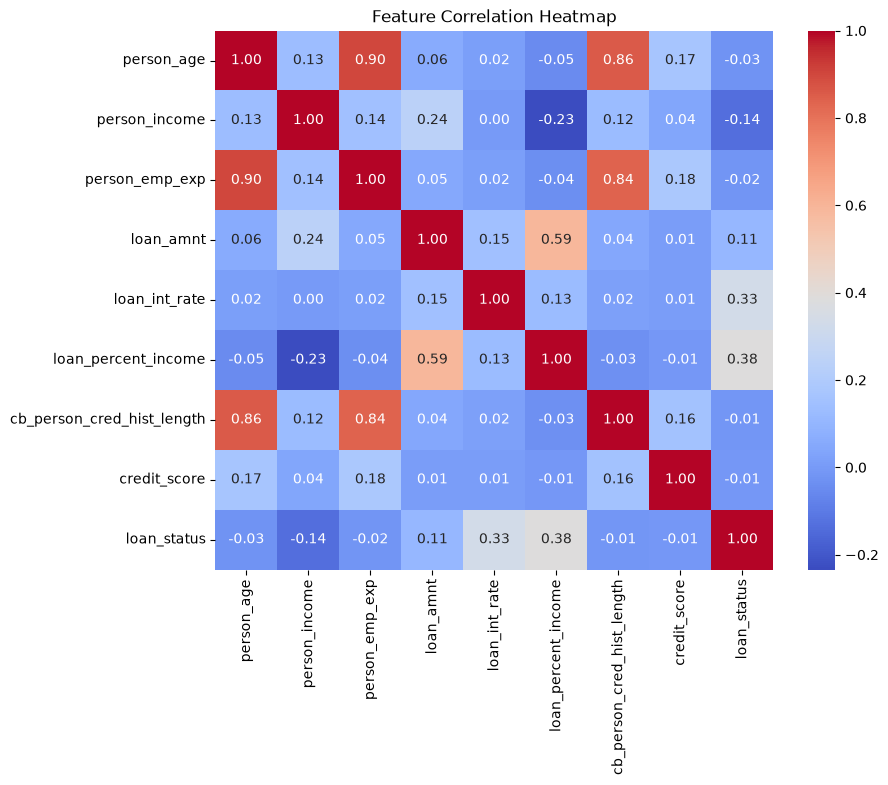

In [34]:
plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [35]:
x = new_df_cap.drop(columns = 'loan_status')
y = new_df_cap['loan_status']

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
x_train.shape

(36000, 13)

In [38]:
x_test.shape

(9000, 13)

In [39]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy='minority',random_state=42)

x_train_bal, y_train_bal = ros.fit_resample(x_train,y_train)

print("Before balancing:")
print(y_train.value_counts())

print("\nAfter balancing:")
print(y_train_bal.value_counts())

Before balancing:
loan_status
0    28000
1     8000
Name: count, dtype: int64

After balancing:
loan_status
0    28000
1    28000
Name: count, dtype: int64


In [40]:

new_df_cap['person_education'].value_counts()

person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

In [41]:
transformer = ColumnTransformer(transformers=[('label', OrdinalEncoder(), ['person_gender', 'previous_loan_defaults_on_file']),
                                             ('Ordinal',OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']]),['person_education']),
                                             ('OneHot',OneHotEncoder(sparse_output=False,drop='first'),['person_home_ownership', 'loan_intent']),
                                             ('Scalar',StandardScaler(),['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                'credit_score'])])

In [42]:
x_train_transformed = transformer.fit_transform(x_train_bal)
x_test_transformed = transformer.transform(x_test)

In [43]:
print(x_train_transformed.shape)
print(x_test_transformed.shape)

(56000, 19)
(9000, 19)


In [44]:
model = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=14,min_samples_leaf=1,max_features="sqrt")


In [45]:
pipe = Pipeline([
    ('preprocessor', transformer),
    ('model', model)
])

pipe.fit(x_train_bal, y_train_bal)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['person_age','person_gender','person_education',..., 'cb_person_cred_hist_length','credit_score', 'previous_loan_defaults_on_file']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('label', ...), ('Ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped.

In [207]:
preds = model.predict(x_test_transformed)
acc = accuracy_score(y_test, preds)
print(f"Random Forest: {round(acc*100,2)}%")

Random Forest: 91.37%


In [208]:
print(classification_report(y_test, preds, target_names=["Not Approved", "Approved"]))


              precision    recall  f1-score   support

Not Approved       0.96      0.92      0.94      7000
    Approved       0.77      0.88      0.82      2000

    accuracy                           0.91      9000
   macro avg       0.86      0.90      0.88      9000
weighted avg       0.92      0.91      0.92      9000



In [ ]:
plt.figure(figsize = (5, 4))
sns.heatmap(confusion_matrix(y_test, preds), cmap = 'viridis', annot = True, fmt = 'd')